In [ ]:
# Import libraries
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
# 1. Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data
y = mnist.target.astype(int)
print("Dataset shape:", X.shape)

Dataset shape: (70000, 784)


In [ ]:
X, y = X[:10000], y[:10000]

In [ ]:
# 2. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 3. Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# 4. ANN / MLP
ann = MLPClassifier(hidden_layer_sizes=(100,),max_iter=50,random_state=42)
ann.fit(X_train, y_train)
y_pred_ann = ann.predict(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# 5. SVM
svm = SVC(kernel='linear',random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

In [ ]:
# 6. KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [ ]:
# 7. Evaluation Function
def evaluate_model(name, y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred,average='weighted')
    recall = recall_score(y_test, y_pred,average='weighted')
    f1 = f1_score(y_test, y_pred,average='weighted')
    print("\n", name)
    print("-------------------------")
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall :", round(recall, 4))
    print("F1-Score :", round(f1, 4))

In [ ]:
# 8. Compare models
evaluate_model("ANN (MLP)", y_test, y_pred_ann)
evaluate_model("SVM", y_test, y_pred_svm)
evaluate_model("KNN", y_test, y_pred_knn)


 ANN (MLP)
-------------------------
Accuracy : 0.947
Precision: 0.947
Recall : 0.947
F1-Score : 0.9469

 SVM
-------------------------
Accuracy : 0.923
Precision: 0.9229
Recall : 0.923
F1-Score : 0.9226

 KNN
-------------------------
Accuracy : 0.912
Precision: 0.9127
Recall : 0.912
F1-Score : 0.9116


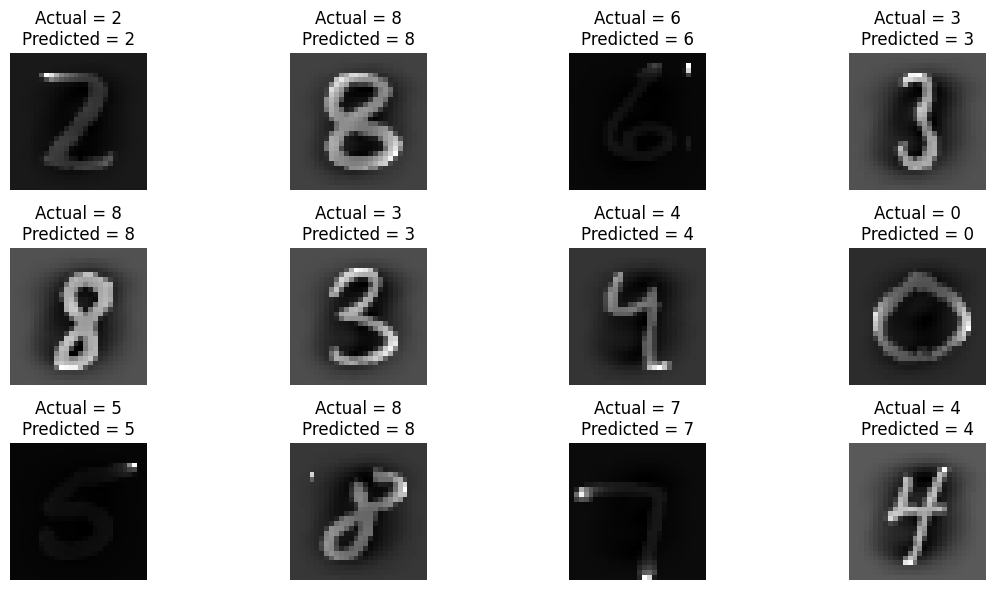

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

correct = np.where(y_test == y_pred_ann)[0]

plt.figure(figsize=(12, 6))

for i in range(12):
    index = correct[i]

    plt.subplot(3, 4, i + 1)
    plt.imshow(
        X_test[index].reshape(28, 28),
        cmap='gray'
    )

    plt.title(
        "Actual = " + str(y_test[index]) +
        "\nPredicted = " + str(y_pred_ann[index])
    )

    plt.axis('off')

plt.tight_layout()
plt.show()